# Notebook 02 — Dataset Description and Exploratory Analysis for AMP Discovery

This notebook characterizes a curated Peptipedia-derived AMP dataset using interpretable sequence-level descriptors. The goal is to generate the first analytical layer of the demonstrative case study: dataset composition, physicochemical properties, amino acid composition, entropy/complexity, approximate secondary-structure propensities, statistical comparisons, and low-dimensional projections.

**Expected input:** a CSV file with at least:

- `sequence`: peptide sequence
- `Antimicrobial` or `label`: binary AMP annotation

**Main outputs:**

- `outputs/amp_dataset_with_descriptors.csv`
- `outputs/amp_descriptor_matrix.csv`
- `outputs/dataset_summary.csv`
- `outputs/statistical_comparison_descriptors.csv`
- figures in `outputs/figures/`


In [1]:
# ============================================================
# 1. Imports and configuration
# ============================================================

from __future__ import annotations

import math
import re
import warnings
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy as scipy_entropy
from scipy.stats import mannwhitneyu

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

In [2]:
# -----------------------------
# Input / output configuration
# -----------------------------

INPUT_PATH = Path("../results/preprocessed_dataset.csv") 
OUTPUT_DIR = Path("../outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
FIGURE_DIR.mkdir(exist_ok=True, parents=True)

# -----------------------------
# Dataset settings
# -----------------------------

SEQUENCE_COL = "sequence"
LABEL_COL_CANDIDATES = ["label"]
POSITIVE_LABEL_NAME = "AMP"
NEGATIVE_LABEL_NAME = "non-AMP"

CANONICAL_AA = list("ACDEFGHIKLMNPQRSTVWY")
CANONICAL_AA_SET = set(CANONICAL_AA)

RANDOM_STATE = 42
FIG_DPI = 300

sns.set_theme(style="whitegrid", context="notebook")


## 2. Load dataset

The notebook automatically detects the binary label column using either `label` or `Antimicrobial`.

In [4]:
# ============================================================
# 2. Load dataset
# ============================================================

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Input file not found: {INPUT_PATH.resolve()}"
        "Place the dataset in the notebook directory or update INPUT_PATH."
    )

df = pd.read_csv(INPUT_PATH)

if SEQUENCE_COL not in df.columns:
    raise ValueError(f"Expected sequence column '{SEQUENCE_COL}' not found. Available columns: {list(df.columns)[:20]}...")

label_col = None
for col in LABEL_COL_CANDIDATES:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    raise ValueError(f"No label column found. Expected one of: {LABEL_COL_CANDIDATES}")

# Standardize sequence and label fields
working_df = df.copy()
working_df[SEQUENCE_COL] = working_df[SEQUENCE_COL].astype(str).str.strip().str.upper()
working_df["label"] = working_df[label_col].fillna(0).astype(int)
working_df["label_name"] = working_df["label"].map({1: POSITIVE_LABEL_NAME, 0: NEGATIVE_LABEL_NAME})

print(f"Loaded dataset: {working_df.shape[0]:,} sequences x {working_df.shape[1]:,} columns")
print(f"Detected label column: {label_col}")
working_df[[SEQUENCE_COL, "label", "label_name"]].head()


Loaded dataset: 47,175 sequences x 3 columns
Detected label column: label


,sequence,label,label_name
0,RIQQIEQKIHHIEQRIQQIEQLLQLTVWGIKQLQARIL,1,AMP
1,LHYNWIDCCHYGVSDCC,0,non-AMP
2,WDEDGAKRIPVDVSE,0,non-AMP
3,RQIKKAFRKMA,1,AMP
4,MKIKTGARILALSALTTMMFSASALAK,0,non-AMP


## 3. Basic quality checks

This section verifies sequence validity, duplicated sequences, missing values, and class balance. If the dataset has already been curated, these steps should mostly confirm the expected state.

In [5]:
# ============================================================
# 3. Basic quality checks
# ============================================================

def is_canonical_sequence(seq: str) -> bool:
    return set(seq).issubset(CANONICAL_AA_SET)

working_df["length"] = working_df[SEQUENCE_COL].str.len()
working_df["is_canonical"] = working_df[SEQUENCE_COL].apply(is_canonical_sequence)
working_df["is_duplicate_sequence"] = working_df.duplicated(subset=[SEQUENCE_COL], keep=False)

basic_summary = pd.DataFrame({
    "metric": [
        "Total sequences",
        "Unique sequences",
        "Duplicated sequence rows",
        "Missing sequences",
        "Canonical sequences",
        "Non-canonical sequences",
        "Minimum length",
        "Median length",
        "Maximum length",
        "AMP sequences",
        "non-AMP sequences",
        "AMP fraction",
    ],
    "value": [
        len(working_df),
        working_df[SEQUENCE_COL].nunique(),
        int(working_df["is_duplicate_sequence"].sum()),
        int(working_df[SEQUENCE_COL].isna().sum()),
        int(working_df["is_canonical"].sum()),
        int((~working_df["is_canonical"]).sum()),
        int(working_df["length"].min()),
        float(working_df["length"].median()),
        int(working_df["length"].max()),
        int((working_df["label"] == 1).sum()),
        int((working_df["label"] == 0).sum()),
        float((working_df["label"] == 1).mean()),
    ]
})

basic_summary.to_csv(OUTPUT_DIR / "dataset_summary.csv", index=False)
basic_summary


,metric,value
0,Total sequences,47175.000000
1,Unique sequences,47175.000000
2,Duplicated sequence rows,0.000000
3,Missing sequences,0.000000
4,Canonical sequences,47175.000000
5,Non-canonical sequences,0.000000
6,Minimum length,5.000000
7,Median length,17.000000
8,Maximum length,60.000000
9,AMP sequences,16514.000000


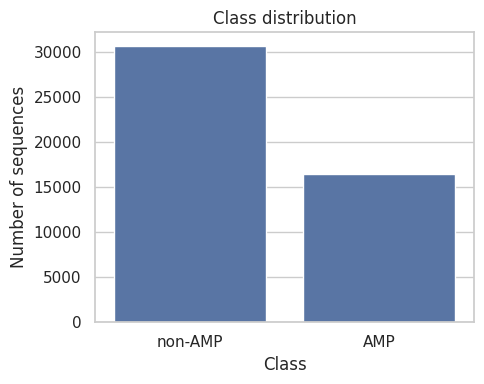

In [6]:
# Class balance figure
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=working_df, x="label_name", order=[NEGATIVE_LABEL_NAME, POSITIVE_LABEL_NAME])
ax.set_xlabel("Class")
ax.set_ylabel("Number of sequences")
ax.set_title("Class distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "class_distribution.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


## 4. Descriptor functions

Descriptors are grouped into:

1. **Composition:** amino acid composition frequencies.
2. **Complexity:** Shannon entropy, normalized entropy, unique residue fraction.
3. **Charge-related descriptors:** approximate net charge at pH 7.4, positive/negative fractions, pI approximation.
4. **Hydrophobicity and composition:** GRAVY, hydrophobic/aromatic/polar fractions.
5. **Stability-like descriptors:** molecular weight, aliphatic index, instability index approximation.
6. **Secondary-structure propensities:** helix, turn, and sheet propensity averages using standard amino-acid propensity scales.

The implementation is dependency-light and does not require Biopython. When Biopython is installed, the notebook can optionally compare with `ProteinAnalysis`, but all core outputs are computed internally.

In [7]:
# ============================================================
# 4. Descriptor functions
# ============================================================

# Average residue masses, excluding water released in peptide bond formation is approximated later.
AA_MASS = {
    "A": 89.09, "C": 121.16, "D": 133.10, "E": 147.13, "F": 165.19,
    "G": 75.07, "H": 155.16, "I": 131.17, "K": 146.19, "L": 131.17,
    "M": 149.21, "N": 132.12, "P": 115.13, "Q": 146.15, "R": 174.20,
    "S": 105.09, "T": 119.12, "V": 117.15, "W": 204.23, "Y": 181.19,
}

# Kyte-Doolittle hydropathy scale
KD_HYDROPATHY = {
    "A": 1.8, "C": 2.5, "D": -3.5, "E": -3.5, "F": 2.8,
    "G": -0.4, "H": -3.2, "I": 4.5, "K": -3.9, "L": 3.8,
    "M": 1.9, "N": -3.5, "P": -1.6, "Q": -3.5, "R": -4.5,
    "S": -0.8, "T": -0.7, "V": 4.2, "W": -0.9, "Y": -1.3,
}

# Guruprasad instability weights are complex pairwise values. Here we provide a lightweight instability proxy
# based on enrichment of known destabilizing/flexible residues. For production, replace with BioPython if needed.
DESTABILIZING_RESIDUES = set("DEKRNQPS")

HYDROPHOBIC_AA = set("AILMFWYV")
AROMATIC_AA = set("FWY")
POSITIVE_AA = set("KRH")
NEGATIVE_AA = set("DE")
POLAR_AA = set("STNQCY")
SMALL_AA = set("AGSTCPDNV")

# Chou-Fasman-like secondary structure propensities
HELIX_PROPENSITY = {
    "A": 1.45, "C": 0.77, "D": 0.98, "E": 1.53, "F": 1.12,
    "G": 0.53, "H": 1.24, "I": 1.00, "K": 1.07, "L": 1.34,
    "M": 1.20, "N": 0.73, "P": 0.59, "Q": 1.17, "R": 0.79,
    "S": 0.79, "T": 0.82, "V": 1.14, "W": 1.14, "Y": 0.61,
}

SHEET_PROPENSITY = {
    "A": 0.97, "C": 1.30, "D": 0.80, "E": 0.26, "F": 1.28,
    "G": 0.81, "H": 0.71, "I": 1.60, "K": 0.74, "L": 1.22,
    "M": 1.67, "N": 0.65, "P": 0.62, "Q": 1.23, "R": 0.90,
    "S": 0.72, "T": 1.20, "V": 1.65, "W": 1.19, "Y": 1.29,
}

TURN_PROPENSITY = {
    "A": 0.66, "C": 1.19, "D": 1.46, "E": 0.74, "F": 0.60,
    "G": 1.56, "H": 0.95, "I": 0.47, "K": 1.01, "L": 0.59,
    "M": 0.60, "N": 1.56, "P": 1.52, "Q": 0.98, "R": 0.95,
    "S": 1.43, "T": 0.96, "V": 0.50, "W": 0.96, "Y": 1.14,
}

# Approximate pKa values for net charge calculation
PKA = {
    "N_TERM": 9.69,
    "C_TERM": 2.34,
    "K": 10.5,
    "R": 12.5,
    "H": 6.0,
    "D": 3.9,
    "E": 4.1,
    "C": 8.3,
    "Y": 10.1,
}


def amino_acid_counts(seq: str) -> Dict[str, int]:
    return {aa: seq.count(aa) for aa in CANONICAL_AA}


def amino_acid_composition(seq: str) -> Dict[str, float]:
    n = len(seq)
    if n == 0:
        return {f"AAC_{aa}": np.nan for aa in CANONICAL_AA}
    return {f"AAC_{aa}": seq.count(aa) / n for aa in CANONICAL_AA}


def sequence_entropy(seq: str, normalized: bool = False) -> float:
    n = len(seq)
    if n == 0:
        return np.nan
    counts = np.array([seq.count(aa) for aa in CANONICAL_AA], dtype=float)
    probs = counts[counts > 0] / n
    h = -np.sum(probs * np.log2(probs))
    if normalized:
        return h / np.log2(len(CANONICAL_AA))
    return h


def fraction_of(seq: str, aa_set: set[str]) -> float:
    n = len(seq)
    if n == 0:
        return np.nan
    return sum(1 for aa in seq if aa in aa_set) / n


def molecular_weight(seq: str) -> float:
    if len(seq) == 0:
        return np.nan
    # Peptide mass approximation: sum free residue masses - water for each peptide bond
    return sum(AA_MASS.get(aa, 0.0) for aa in seq) - (len(seq) - 1) * 18.015


def gravy(seq: str) -> float:
    if len(seq) == 0:
        return np.nan
    return float(np.mean([KD_HYDROPATHY[aa] for aa in seq]))


def aliphatic_index(seq: str) -> float:
    # Ikai aliphatic index approximation
    n = len(seq)
    if n == 0:
        return np.nan
    x_a = seq.count("A") / n * 100
    x_v = seq.count("V") / n * 100
    x_i = seq.count("I") / n * 100
    x_l = seq.count("L") / n * 100
    return x_a + 2.9 * x_v + 3.9 * (x_i + x_l)


def instability_proxy(seq: str) -> float:
    # Lightweight proxy: percentage of destabilizing/flexible residues.
    # Useful as an interpretable descriptor, not a replacement for the exact Guruprasad index.
    return 100 * fraction_of(seq, DESTABILIZING_RESIDUES)


def net_charge(seq: str, ph: float = 7.4) -> float:
    # Henderson-Hasselbalch approximation
    charge = 0.0
    # N-terminus positive
    charge += 1 / (1 + 10 ** (ph - PKA["N_TERM"]))
    # C-terminus negative
    charge -= 1 / (1 + 10 ** (PKA["C_TERM"] - ph))

    for aa in seq:
        if aa in ["K", "R", "H"]:
            charge += 1 / (1 + 10 ** (ph - PKA[aa]))
        elif aa in ["D", "E", "C", "Y"]:
            charge -= 1 / (1 + 10 ** (PKA[aa] - ph))
    return charge


def approximate_pI(seq: str) -> float:
    # Brute-force approximate pI as pH where absolute charge is minimized
    if len(seq) == 0:
        return np.nan
    ph_grid = np.linspace(2.0, 12.0, 1001)
    charges = np.array([net_charge(seq, ph=ph) for ph in ph_grid])
    return float(ph_grid[np.argmin(np.abs(charges))])


def avg_propensity(seq: str, scale: Dict[str, float]) -> float:
    if len(seq) == 0:
        return np.nan
    return float(np.mean([scale[aa] for aa in seq]))


def descriptor_dict(seq: str) -> Dict[str, float]:
    desc = {
        "length": len(seq),
        "molecular_weight": molecular_weight(seq),
        "shannon_entropy": sequence_entropy(seq, normalized=False),
        "normalized_entropy": sequence_entropy(seq, normalized=True),
        "unique_residue_fraction": len(set(seq)) / len(seq) if len(seq) > 0 else np.nan,
        "net_charge_pH_7_4": net_charge(seq, ph=7.4),
        "absolute_charge_pH_7_4": abs(net_charge(seq, ph=7.4)),
        "isoelectric_point_approx": approximate_pI(seq),
        "positive_fraction": fraction_of(seq, POSITIVE_AA),
        "negative_fraction": fraction_of(seq, NEGATIVE_AA),
        "charged_fraction": fraction_of(seq, POSITIVE_AA | NEGATIVE_AA),
        "hydrophobic_fraction": fraction_of(seq, HYDROPHOBIC_AA),
        "polar_fraction": fraction_of(seq, POLAR_AA),
        "aromatic_fraction": fraction_of(seq, AROMATIC_AA),
        "small_fraction": fraction_of(seq, SMALL_AA),
        "gravy": gravy(seq),
        "aliphatic_index": aliphatic_index(seq),
        "instability_proxy": instability_proxy(seq),
        "helix_propensity": avg_propensity(seq, HELIX_PROPENSITY),
        "sheet_propensity": avg_propensity(seq, SHEET_PROPENSITY),
        "turn_propensity": avg_propensity(seq, TURN_PROPENSITY),
    }
    desc.update(amino_acid_composition(seq))
    return desc


## 5. Compute descriptors

This step builds the feature matrix used for downstream exploratory analysis, interpretability, uncertainty-aware modelling, and ranking.

In [8]:
# ============================================================
# 5. Compute descriptors
# ============================================================

# Keep only canonical sequences for descriptor computation.
# If your previous curation already did this, no rows should be removed here.
analysis_df = working_df[working_df["is_canonical"]].copy().reset_index(drop=True)

print(f"Canonical sequences retained for analysis: {len(analysis_df):,}")

feature_records = [descriptor_dict(seq) for seq in analysis_df[SEQUENCE_COL].tolist()]
features_df = pd.DataFrame(feature_records)

# Combine descriptors with metadata
analysis_with_desc = pd.concat(
    [analysis_df[[SEQUENCE_COL, "label", "label_name"]].reset_index(drop=True), features_df],
    axis=1,
)

# Save outputs
analysis_with_desc.to_csv(OUTPUT_DIR / "amp_dataset_with_descriptors.csv", index=False)
features_df.to_csv(OUTPUT_DIR / "amp_descriptor_matrix.csv", index=False)

print(f"Descriptor matrix shape: {features_df.shape}")
analysis_with_desc.head()


Canonical sequences retained for analysis: 47,175
Descriptor matrix shape: (47175, 41)


,sequence,label,label_name,length,molecular_weight,shannon_entropy,normalized_entropy,unique_residue_fraction,net_charge_pH_7_4,absolute_charge_pH_7_4,...,AAC_M,AAC_N,AAC_P,AAC_Q,AAC_R,AAC_S,AAC_T,AAC_V,AAC_W,AAC_Y
0,RIQQIEQKIHHIEQRIQQIEQLLQLTVWGIKQLQARIL,1,AMP,38,4671.505,3.081120,0.712904,0.315789,2.071371,2.071371,...,0.000000,0.000000,0.000000,0.263158,0.078947,0.000000,0.026316,0.026316,0.026316,0.000000
1,LHYNWIDCCHYGVSDCC,0,non-AMP,17,2031.300,3.263933,0.755203,0.647059,-2.379134,2.379134,...,0.000000,0.058824,0.000000,0.000000,0.000000,0.058824,0.000000,0.058824,0.058824,0.117647
2,WDEDGAKRIPVDVSE,0,non-AMP,15,1715.820,3.323231,0.768923,0.733333,-3.003945,3.003945,...,0.000000,0.000000,0.066667,0.000000,0.066667,0.066667,0.000000,0.133333,0.066667,0.000000
3,RQIKKAFRKMA,1,AMP,11,1376.720,2.663533,0.616283,0.636364,4.992509,4.992509,...,0.090909,0.000000,0.000000,0.090909,0.181818,0.000000,0.000000,0.000000,0.000000,0.000000
4,MKIKTGARILALSALTTMMFSASALAK,0,non-AMP,27,2826.460,3.105653,0.718580,0.370370,3.992517,3.992517,...,0.111111,0.000000,0.000000,0.000000,0.037037,0.111111,0.111111,0.000000,0.000000,0.000000


## 6. Descriptor groups

These groups make it easier to create targeted figures and interpret the dataset in biologically meaningful categories.

In [9]:
# ============================================================
# 6. Descriptor groups
# ============================================================

aac_cols = [f"AAC_{aa}" for aa in CANONICAL_AA]
complexity_cols = ["length", "shannon_entropy", "normalized_entropy", "unique_residue_fraction"]
charge_cols = ["net_charge_pH_7_4", "absolute_charge_pH_7_4", "isoelectric_point_approx", "positive_fraction", "negative_fraction", "charged_fraction"]
hydrophobicity_cols = ["gravy", "hydrophobic_fraction", "polar_fraction", "aromatic_fraction", "small_fraction"]
stability_cols = ["molecular_weight", "aliphatic_index", "instability_proxy"]
structure_cols = ["helix_propensity", "sheet_propensity", "turn_propensity"]

core_descriptor_cols = complexity_cols + charge_cols + hydrophobicity_cols + stability_cols + structure_cols
all_descriptor_cols = core_descriptor_cols + aac_cols

print(f"Core descriptors: {len(core_descriptor_cols)}")
print(f"AAC descriptors: {len(aac_cols)}")
print(f"Total descriptors: {len(all_descriptor_cols)}")


Core descriptors: 21
AAC descriptors: 20
Total descriptors: 41


## 7. Univariate descriptor summaries

This section compares AMP and non-AMP classes across interpretable descriptors.

In [10]:
# ============================================================
# 7. Univariate descriptor summaries
# ============================================================

summary_by_class = (
    analysis_with_desc
    .groupby("label_name")[core_descriptor_cols]
    .agg(["mean", "std", "median", "min", "max"])
)

summary_by_class.to_csv(OUTPUT_DIR / "descriptor_summary_by_class.csv")
summary_by_class


length                           shannon_entropy            \
                 mean        std median min max            mean       std   
label_name                                                                  
AMP         20.620080  13.083122   15.0   5  60        2.797431  0.735469   
non-AMP     21.586217  13.580839   18.0   5  60        3.035612  0.556973   

                                     ... sheet_propensity                      \
              median  min       max  ...             mean       std    median   
label_name                           ...                                        
AMP         2.899397 -0.0  4.202580  ...         1.032338  0.095207  1.035000   
non-AMP     3.121928 -0.0  4.321928  ...         1.016477  0.106143  1.018667   

                            turn_propensity                                \
              min       max            mean       std    median       min   
label_name                                                                  
AMP         0.448  1.521429        0.945034  0.119400  0.939333  0.567647   
non-AMP     0.260  1.578000        0.987626  0.120706  0.985714  0.526000   

                   
              max  
label_name         
AMP         1.534  
non-AMP     1.560  

[2 rows x 105 columns]

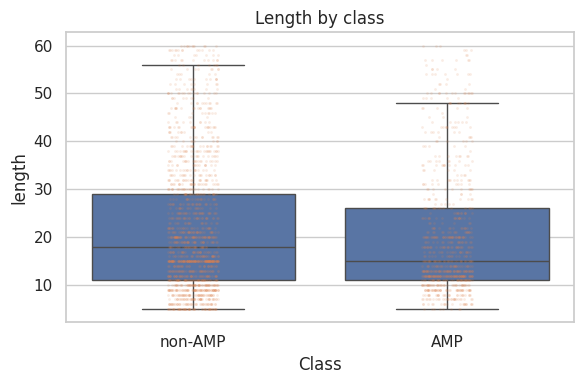

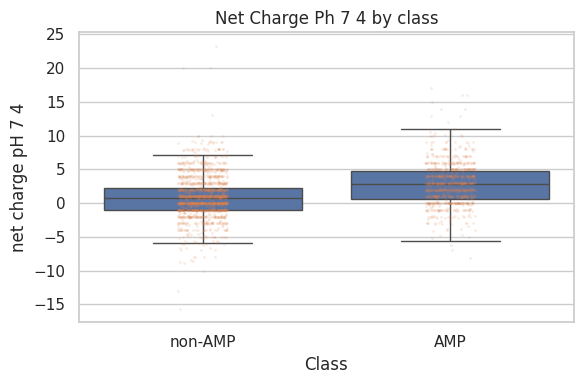

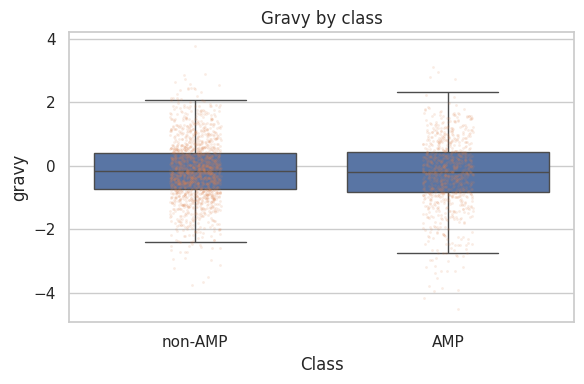

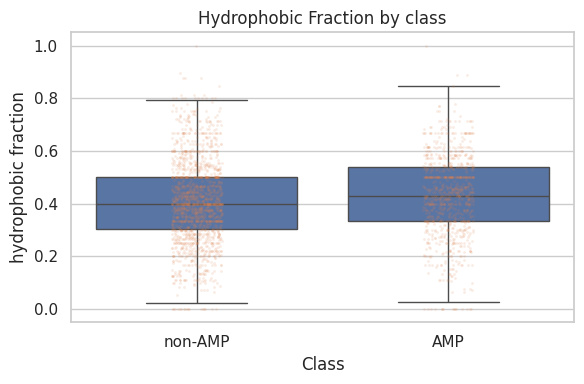

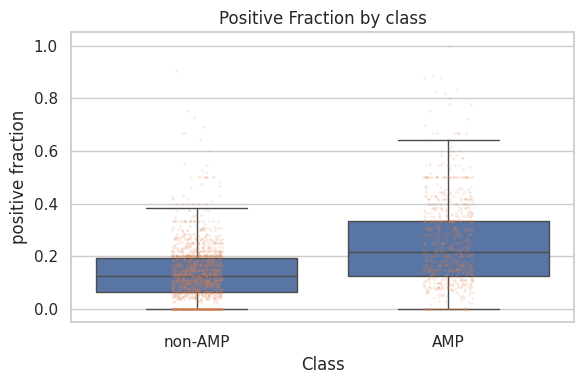

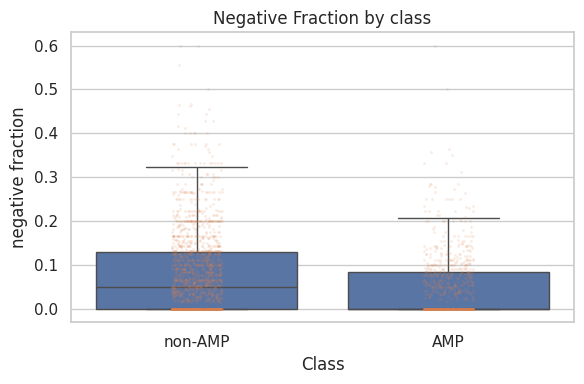

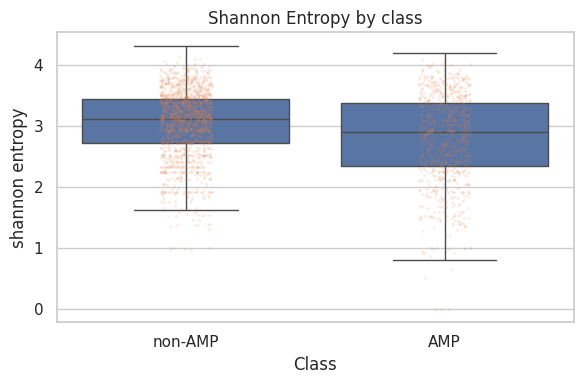

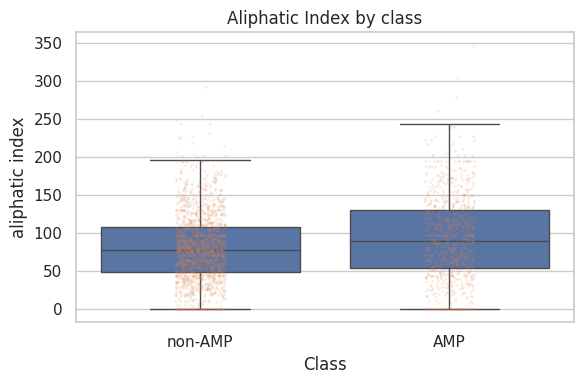

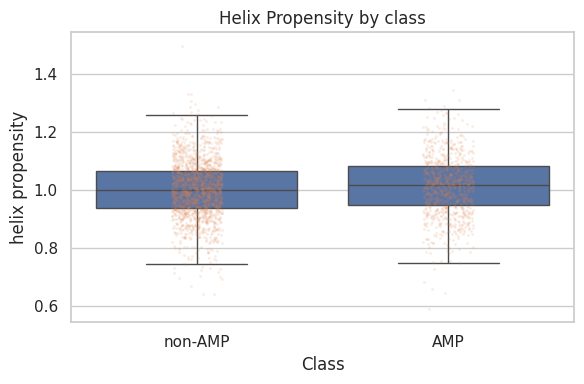

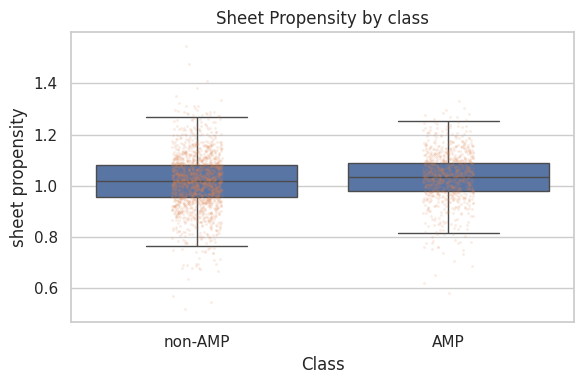

In [11]:
# Plot selected descriptor distributions
selected_descriptors = [
    "length",
    "net_charge_pH_7_4",
    "gravy",
    "hydrophobic_fraction",
    "positive_fraction",
    "negative_fraction",
    "shannon_entropy",
    "aliphatic_index",
    "helix_propensity",
    "sheet_propensity",
]

for col in selected_descriptors:
    plt.figure(figsize=(6, 4))
    ax = sns.boxplot(data=analysis_with_desc, x="label_name", y=col, order=[NEGATIVE_LABEL_NAME, POSITIVE_LABEL_NAME], showfliers=False)
    sns.stripplot(data=analysis_with_desc.sample(min(len(analysis_with_desc), 2500), random_state=RANDOM_STATE),
                  x="label_name", y=col, order=[NEGATIVE_LABEL_NAME, POSITIVE_LABEL_NAME], alpha=0.15, size=2)
    ax.set_xlabel("Class")
    ax.set_ylabel(col.replace("_", " "))
    ax.set_title(f"{col.replace('_', ' ').title()} by class")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"boxplot_{col}.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()


## 8. Amino acid composition analysis

This section compares average amino acid frequencies between AMP and non-AMP peptides.

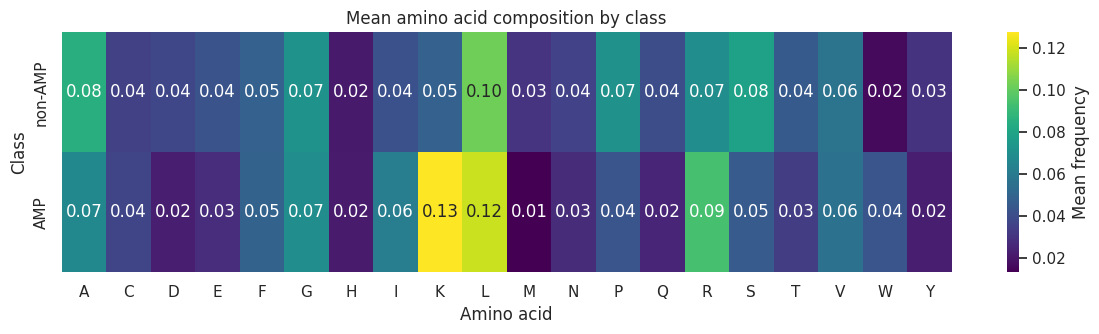

In [12]:
# ============================================================
# 8. Amino acid composition analysis
# ============================================================

aac_mean = (
    analysis_with_desc
    .groupby("label_name")[aac_cols]
    .mean()
    .loc[[NEGATIVE_LABEL_NAME, POSITIVE_LABEL_NAME]]
)

aac_mean_renamed = aac_mean.copy()
aac_mean_renamed.columns = [col.replace("AAC_", "") for col in aac_mean_renamed.columns]

aac_mean_renamed.to_csv(OUTPUT_DIR / "aac_mean_by_class.csv")

plt.figure(figsize=(12, 3.5))
ax = sns.heatmap(aac_mean_renamed, annot=True, fmt=".2f", cmap="viridis", cbar_kws={"label": "Mean frequency"})
ax.set_xlabel("Amino acid")
ax.set_ylabel("Class")
ax.set_title("Mean amino acid composition by class")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "aac_heatmap_by_class.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


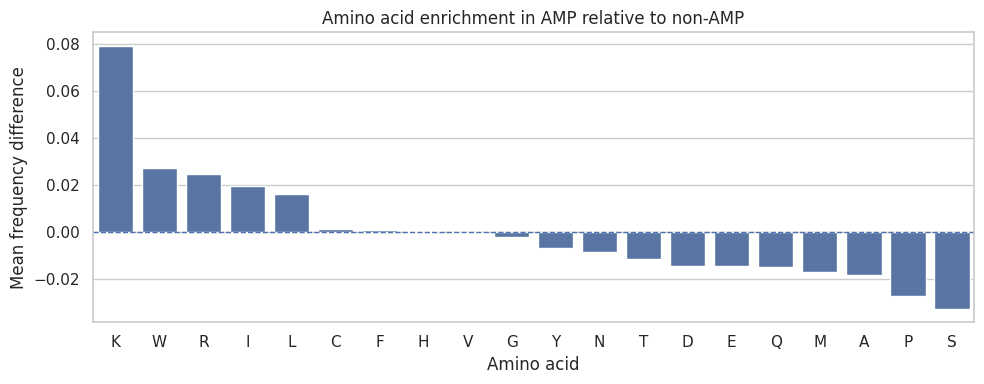

In [13]:
# Difference in amino acid composition: AMP - non-AMP
amp_minus_nonamp = aac_mean.loc[POSITIVE_LABEL_NAME] - aac_mean.loc[NEGATIVE_LABEL_NAME]
amp_minus_nonamp.index = [idx.replace("AAC_", "") for idx in amp_minus_nonamp.index]
amp_minus_nonamp = amp_minus_nonamp.sort_values(ascending=False)

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=amp_minus_nonamp.index, y=amp_minus_nonamp.values)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Amino acid")
ax.set_ylabel("Mean frequency difference")
ax.set_title("Amino acid enrichment in AMP relative to non-AMP")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "aac_difference_amp_minus_nonamp.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

amp_minus_nonamp.to_csv(OUTPUT_DIR / "aac_difference_amp_minus_nonamp.csv", header=["AMP_minus_nonAMP"])


## 9. Statistical comparison between classes

Mann–Whitney U tests are used as non-parametric comparisons. Cliff's delta is included as an effect-size estimate.

In [14]:
# ============================================================
# 9. Statistical comparison between classes
# ============================================================

def cliffs_delta(x: Iterable[float], y: Iterable[float]) -> float:
    # Compute Cliff's delta effect size.
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    y = np.asarray(pd.Series(y).dropna(), dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    # Efficient pairwise comparison using sorting
    y_sorted = np.sort(y)
    greater = np.searchsorted(y_sorted, x, side="left").sum()
    less = (len(y) - np.searchsorted(y_sorted, x, side="right")).sum()
    return (greater - less) / (len(x) * len(y))

stat_records = []

for col in all_descriptor_cols:
    x = analysis_with_desc.loc[analysis_with_desc["label"] == 1, col]
    y = analysis_with_desc.loc[analysis_with_desc["label"] == 0, col]
    try:
        stat, p_value = mannwhitneyu(x, y, alternative="two-sided")
    except Exception:
        stat, p_value = np.nan, np.nan
    stat_records.append({
        "descriptor": col,
        "mean_AMP": x.mean(),
        "mean_nonAMP": y.mean(),
        "median_AMP": x.median(),
        "median_nonAMP": y.median(),
        "mean_difference_AMP_minus_nonAMP": x.mean() - y.mean(),
        "mannwhitney_u": stat,
        "p_value": p_value,
        "cliffs_delta_AMP_vs_nonAMP": cliffs_delta(x, y),
    })

stats_df = pd.DataFrame(stat_records)
stats_df["minus_log10_pvalue"] = -np.log10(stats_df["p_value"].replace(0, np.nextafter(0, 1)))
stats_df = stats_df.sort_values("p_value", ascending=True)

stats_df.to_csv(OUTPUT_DIR / "statistical_comparison_descriptors.csv", index=False)
stats_df.head(20)


,descriptor,mean_AMP,mean_nonAMP,median_AMP,median_nonAMP,mean_difference_AMP_minus_nonAMP,mannwhitney_u,p_value,cliffs_delta_AMP_vs_nonAMP,minus_log10_pvalue
7,positive_fraction,0.242068,0.137653,0.216216,0.127273,0.104415,358610805.5,0.000000e+00,0.416494,323.306215
6,isoelectric_point_approx,9.413953,7.987086,10.360000,8.250000,1.426867,319317370.5,0.000000e+00,0.261287,323.306215
5,absolute_charge_pH_7_4,3.360733,2.266182,2.992525,1.453231,1.094551,320766559.0,0.000000e+00,0.267011,323.306215
4,net_charge_pH_7_4,2.695018,0.952188,2.768894,0.802530,1.742830,335729542.0,0.000000e+00,0.326114,323.306215
12,polar_fraction,0.189605,0.262970,0.166667,0.254545,-0.073365,177809568.0,0.000000e+00,-0.297661,323.306215
14,small_fraction,0.398824,0.513679,0.416667,0.518519,-0.114855,169185372.0,0.000000e+00,-0.331727,323.306215
9,charged_fraction,0.292217,0.217046,0.283019,0.200000,0.075171,331001066.0,0.000000e+00,0.307437,323.306215
20,turn_propensity,0.945034,0.987626,0.939333,0.985714,-0.042592,199646716.0,0.000000e+00,-0.211406,323.306215
31,AAC_M,0.012982,0.030003,0.000000,0.000000,-0.017021,186248336.0,0.000000e+00,-0.264329,323.306215
29,AAC_K,0.127340,0.047878,0.090909,0.023810,0.079462,351203430.0,0.000000e+00,0.387235,323.306215


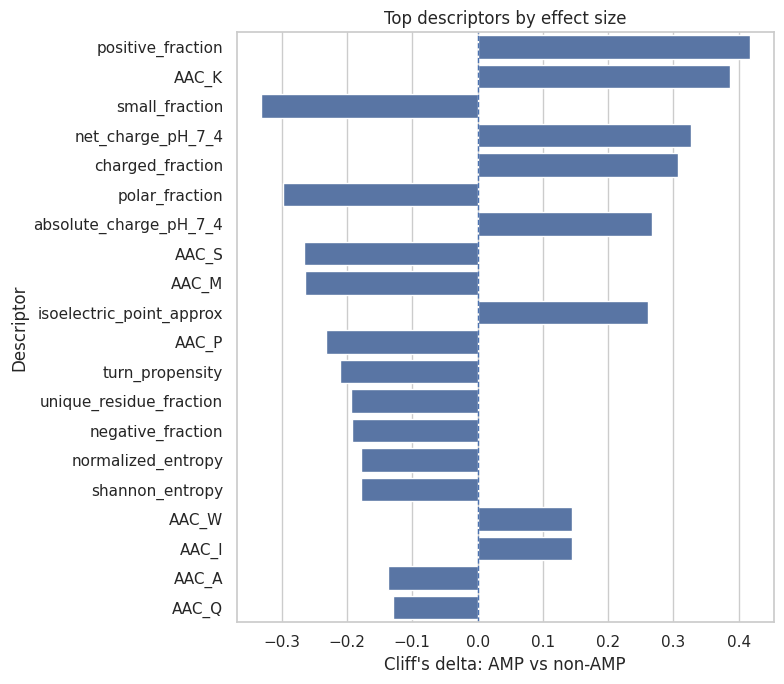

In [15]:
# Plot top descriptors by absolute effect size
plot_stats = stats_df.copy()
plot_stats["abs_cliffs_delta"] = plot_stats["cliffs_delta_AMP_vs_nonAMP"].abs()
plot_stats = plot_stats.sort_values("abs_cliffs_delta", ascending=False).head(20)

plt.figure(figsize=(8, 7))
ax = sns.barplot(data=plot_stats, y="descriptor", x="cliffs_delta_AMP_vs_nonAMP")
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Cliff's delta: AMP vs non-AMP")
ax.set_ylabel("Descriptor")
ax.set_title("Top descriptors by effect size")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_descriptors_by_effect_size.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


## 10. Correlation structure

This section evaluates redundancy among descriptors. Highly correlated variables may later be handled by feature selection or grouped interpretation.

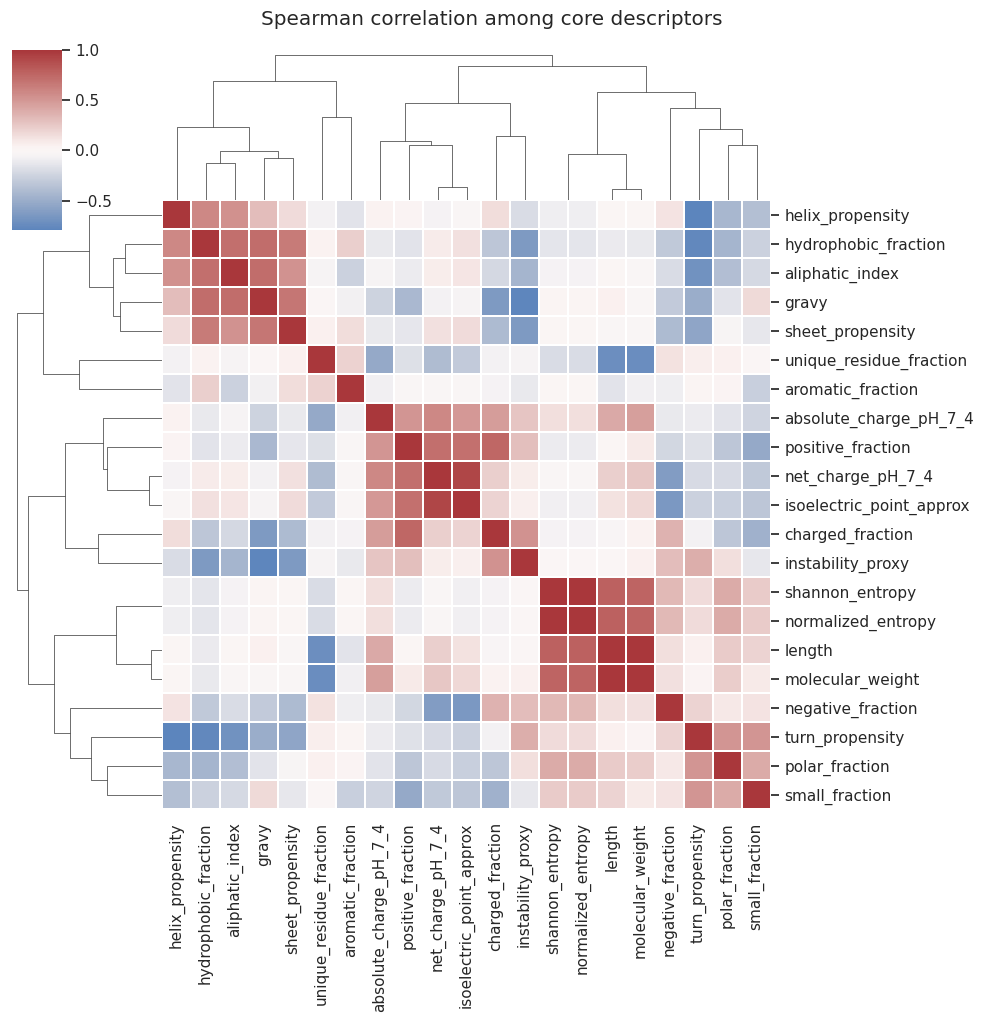

In [16]:
# ============================================================
# 10. Correlation analysis
# ============================================================

corr = analysis_with_desc[all_descriptor_cols].corr(method="spearman")
corr.to_csv(OUTPUT_DIR / "spearman_correlation_descriptors.csv")

# Core descriptor clustermap
core_corr = analysis_with_desc[core_descriptor_cols].corr(method="spearman")

g = sns.clustermap(core_corr, cmap="vlag", center=0, figsize=(10, 10), linewidths=0.2)
g.fig.suptitle("Spearman correlation among core descriptors", y=1.02)
g.savefig(FIGURE_DIR / "core_descriptor_correlation_clustermap.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


## 11. Low-dimensional projections

PCA is used to inspect whether AMP and non-AMP peptides show broad separability using interpretable descriptors only. This is not intended as a definitive classifier, but as exploratory evidence of dataset structure.

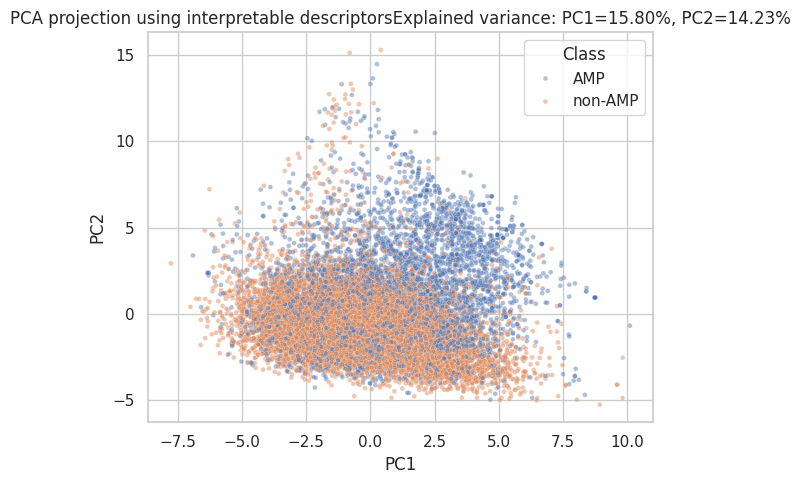

In [17]:
# ============================================================
# 11. PCA projection
# ============================================================

X = analysis_with_desc[all_descriptor_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = analysis_with_desc["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "label": y,
    "label_name": analysis_with_desc["label_name"].values,
})

pca_df.to_csv(OUTPUT_DIR / "pca_projection.csv", index=False)

plt.figure(figsize=(6, 5))
# Sample for lighter plotting if needed
plot_pca_df = pca_df.sample(min(len(pca_df), 15000), random_state=RANDOM_STATE)
ax = sns.scatterplot(data=plot_pca_df, x="PC1", y="PC2", hue="label_name", alpha=0.45, s=12)
ax.set_title(
    "PCA projection using interpretable descriptors"
    f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.legend(title="Class")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pca_descriptor_projection.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


## 12. Optional UMAP projection

UMAP is useful for visualization, but it is optional. If `umap-learn` is not installed, this section is skipped automatically.

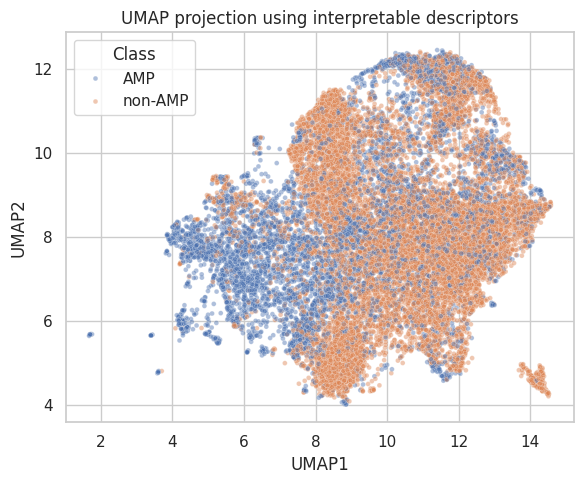

In [18]:
# ============================================================
# 12. Optional UMAP projection
# ============================================================

try:
    import umap

    # UMAP can be slow for very large datasets. Use a reproducible sample for visualization.
    umap_sample_size = min(len(analysis_with_desc), 20000)
    sample_idx = analysis_with_desc.sample(umap_sample_size, random_state=RANDOM_STATE).index

    X_umap_input = X_scaled[sample_idx]
    y_umap = analysis_with_desc.loc[sample_idx, "label"].values
    label_name_umap = analysis_with_desc.loc[sample_idx, "label_name"].values

    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.1,
        metric="euclidean",
        random_state=RANDOM_STATE,
    )
    X_umap = reducer.fit_transform(X_umap_input)

    umap_df = pd.DataFrame({
        "UMAP1": X_umap[:, 0],
        "UMAP2": X_umap[:, 1],
        "label": y_umap,
        "label_name": label_name_umap,
    })
    umap_df.to_csv(OUTPUT_DIR / "umap_projection.csv", index=False)

    plt.figure(figsize=(6, 5))
    ax = sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="label_name", alpha=0.45, s=12)
    ax.set_title("UMAP projection using interpretable descriptors")
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    plt.legend(title="Class")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "umap_descriptor_projection.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

except ImportError:
    print("umap-learn is not installed. Skipping UMAP. Install with: pip install umap-learn")


## 13. Dataset complexity and class overlap

This section gives simple geometry-based indicators of class overlap using the descriptor space. These values are useful for explaining why the task should not be treated as a trivial AMP/non-AMP classification problem.

In [19]:
# ============================================================
# 13. Dataset complexity and class overlap
# ============================================================

# Use a sample for pairwise distances to avoid memory issues
complexity_sample_size = min(len(analysis_with_desc), 5000)
complexity_df = analysis_with_desc.sample(complexity_sample_size, random_state=RANDOM_STATE).copy()
X_complexity = scaler.transform(complexity_df[all_descriptor_cols].replace([np.inf, -np.inf], np.nan).fillna(0))
y_complexity = complexity_df["label"].values

# Silhouette score with true labels, not as a clustering validation claim, but as a class-overlap indicator.
try:
    sil = silhouette_score(X_complexity, y_complexity, metric="euclidean")
except Exception:
    sil = np.nan

# Pairwise distance distributions
D = pairwise_distances(X_complexity, metric="euclidean")
labels = y_complexity

within_amp = D[np.ix_(labels == 1, labels == 1)]
within_nonamp = D[np.ix_(labels == 0, labels == 0)]
between = D[np.ix_(labels == 1, labels == 0)]

# Remove diagonals for within-class distances
within_amp_vals = within_amp[np.triu_indices_from(within_amp, k=1)] if within_amp.shape[0] > 1 else np.array([])
within_nonamp_vals = within_nonamp[np.triu_indices_from(within_nonamp, k=1)] if within_nonamp.shape[0] > 1 else np.array([])
between_vals = between.ravel()

complexity_summary = pd.DataFrame({
    "metric": [
        "Silhouette score using AMP/non-AMP labels",
        "Mean within-AMP distance",
        "Mean within-nonAMP distance",
        "Mean between-class distance",
        "Median within-AMP distance",
        "Median within-nonAMP distance",
        "Median between-class distance",
    ],
    "value": [
        sil,
        np.mean(within_amp_vals) if len(within_amp_vals) else np.nan,
        np.mean(within_nonamp_vals) if len(within_nonamp_vals) else np.nan,
        np.mean(between_vals) if len(between_vals) else np.nan,
        np.median(within_amp_vals) if len(within_amp_vals) else np.nan,
        np.median(within_nonamp_vals) if len(within_nonamp_vals) else np.nan,
        np.median(between_vals) if len(between_vals) else np.nan,
    ]
})

complexity_summary.to_csv(OUTPUT_DIR / "dataset_complexity_summary.csv", index=False)
complexity_summary


,metric,value
0,Silhouette score using AMP/non-AMP labels,0.037673
1,Mean within-AMP distance,8.844582
2,Mean within-nonAMP distance,8.375421
3,Mean between-class distance,8.887892
4,Median within-AMP distance,8.566683
5,Median within-nonAMP distance,8.113482
6,Median between-class distance,8.583358


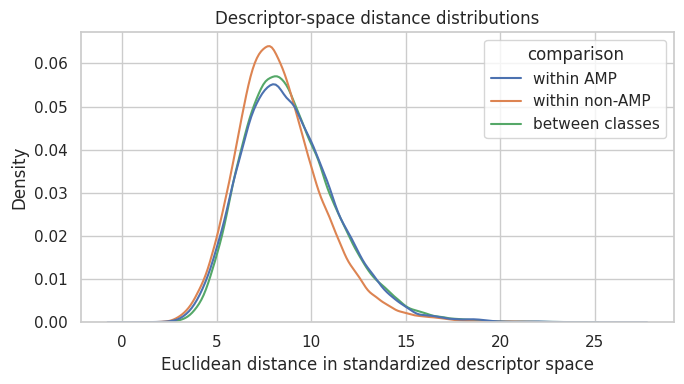

In [20]:
# Distance distribution plot
max_plot_points = 100000
rng = np.random.default_rng(RANDOM_STATE)

def subsample_values(values, max_n=max_plot_points):
    values = np.asarray(values)
    if len(values) <= max_n:
        return values
    idx = rng.choice(len(values), size=max_n, replace=False)
    return values[idx]

distance_plot_df = pd.DataFrame({
    "distance": np.concatenate([
        subsample_values(within_amp_vals),
        subsample_values(within_nonamp_vals),
        subsample_values(between_vals),
    ]),
    "comparison": (
        ["within AMP"] * len(subsample_values(within_amp_vals)) +
        ["within non-AMP"] * len(subsample_values(within_nonamp_vals)) +
        ["between classes"] * len(subsample_values(between_vals))
    )
})

plt.figure(figsize=(7, 4))
ax = sns.kdeplot(data=distance_plot_df, x="distance", hue="comparison", fill=False)
ax.set_title("Descriptor-space distance distributions")
ax.set_xlabel("Euclidean distance in standardized descriptor space")
ax.set_ylabel("Density")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "distance_distributions_descriptor_space.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


## 14. Exploratory feature importance

This is a preliminary analysis to identify descriptors that may contribute to AMP/non-AMP separation. The model here is not the final predictive model; it is used only as an exploratory tool for dataset description.

In [21]:
# ============================================================
# 14. Exploratory Random Forest feature importance
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)

rf.fit(X_scaled, y)

feature_importance_df = pd.DataFrame({
    "descriptor": all_descriptor_cols,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

feature_importance_df.to_csv(OUTPUT_DIR / "exploratory_random_forest_feature_importance.csv", index=False)
feature_importance_df.head(25)


,descriptor,importance
29,AAC_K,0.056174
7,positive_fraction,0.053042
4,net_charge_pH_7_4,0.052316
31,AAC_M,0.051664
6,isoelectric_point_approx,0.038249
15,molecular_weight,0.033465
14,small_fraction,0.032467
12,polar_fraction,0.031587
5,absolute_charge_pH_7_4,0.030597
10,gravy,0.028732


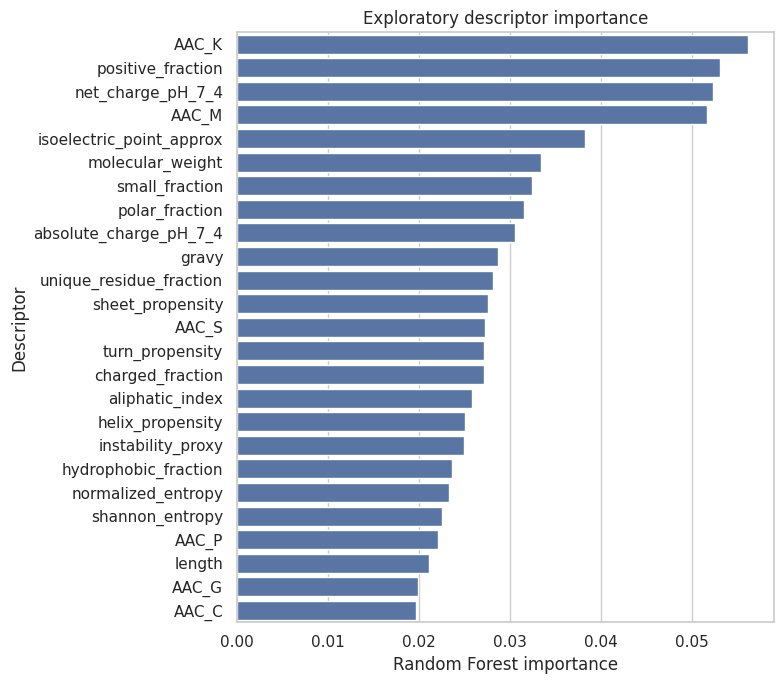

In [22]:
plt.figure(figsize=(8, 7))
plot_imp = feature_importance_df.head(25)
ax = sns.barplot(data=plot_imp, y="descriptor", x="importance")
ax.set_xlabel("Random Forest importance")
ax.set_ylabel("Descriptor")
ax.set_title("Exploratory descriptor importance")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "exploratory_rf_feature_importance.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


## 15. Export modelling-ready descriptor matrix

The exported file includes sequence, label, class name, and all descriptors. This will be used in the next notebook for explainable and uncertainty-aware AMP prediction.

In [24]:
# ============================================================
# 15. Export final files
# ============================================================

model_ready_df = analysis_with_desc[[SEQUENCE_COL, "label", "label_name"] + all_descriptor_cols].copy()
model_ready_df.to_csv(OUTPUT_DIR / "amp_model_ready_descriptors.csv", index=False)

metadata = pd.DataFrame({
    "descriptor_group": (
        ["complexity"] * len(complexity_cols)
        + ["charge"] * len(charge_cols)
        + ["hydrophobicity_composition"] * len(hydrophobicity_cols)
        + ["stability_like"] * len(stability_cols)
        + ["secondary_structure_propensity"] * len(structure_cols)
        + ["amino_acid_composition"] * len(aac_cols)
    ),
    "descriptor": core_descriptor_cols + aac_cols,
})
metadata.to_csv(OUTPUT_DIR / "descriptor_metadata.csv", index=False)

print("Saved outputs:")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"- {path}")

print("Saved figures:")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print(f"- {path}")


Saved outputs:
- ../outputs/aac_difference_amp_minus_nonamp.csv
- ../outputs/aac_mean_by_class.csv
- ../outputs/amp_dataset_with_descriptors.csv
- ../outputs/amp_descriptor_matrix.csv
- ../outputs/amp_model_ready_descriptors.csv
- ../outputs/dataset_complexity_summary.csv
- ../outputs/dataset_summary.csv
- ../outputs/descriptor_metadata.csv
- ../outputs/descriptor_summary_by_class.csv
- ../outputs/exploratory_random_forest_feature_importance.csv
- ../outputs/pca_projection.csv
- ../outputs/spearman_correlation_descriptors.csv
- ../outputs/statistical_comparison_descriptors.csv
- ../outputs/umap_projection.csv
Saved figures:
- ../outputs/figures/aac_difference_amp_minus_nonamp.png
- ../outputs/figures/aac_heatmap_by_class.png
- ../outputs/figures/boxplot_aliphatic_index.png
- ../outputs/figures/boxplot_gravy.png
- ../outputs/figures/boxplot_helix_propensity.png
- ../outputs/figures/boxplot_hydrophobic_fraction.png
- ../outputs/figures/boxplot_length.png
- ../outputs/figures/boxplot_nega

## 16. Suggested manuscript-ready summary

Use the generated files and figures to report:

1. Number of AMP and non-AMP sequences after curation.
2. Sequence-length distribution and class balance.
3. Descriptor-level differences between AMP and non-AMP peptides.
4. Amino acid composition enrichment patterns.
5. Evidence of class overlap in interpretable descriptor space.
6. Preliminary descriptors likely to influence downstream classification and SHAP-based interpretation.

This notebook intentionally avoids overclaiming predictive performance. Its role is dataset characterization, not model benchmarking.